# Data Preparation

Load cleaned order-level data and define cancellation target.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

INPUT_FILE = Path("cleaned_orders_dataset.csv")

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Missing input file: {INPUT_FILE}")

df_raw = pd.read_csv(INPUT_FILE)

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
]
for col in date_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors="coerce")

df_raw["order_status"] = df_raw["order_status"].astype("string").str.strip().str.lower()
df_raw["cancel_flag"] = df_raw["order_status"].isin(["canceled", "unavailable"]).astype(int)

print("Dataset shape:", df_raw.shape)
print("Unique orders:", df_raw["order_id"].nunique())
print("Class distribution:")
print(df_raw["cancel_flag"].value_counts(normalize=True).rename("proportion"))

display(df_raw.head())

Dataset shape: (99441, 25)
Unique orders: 99441
Class distribution:
cancel_flag
0    0.987591
1    0.012409
Name: proportion, dtype: float64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,product_weight_g,product_photos_qty,seller_id,seller_state,total_payment_value,payment_type,payment_installments,review_score,review_creation_date,cancel_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,sp,...,500.0,4.0,3504c0cb71d7fa48d967e0e4c94d59d9,sp,38.71,voucher,1.0,4.0,2017-10-11,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,ba,...,400.0,1.0,289cdb325fb7e7f891c38608bf9e0962,sp,141.46,boleto,1.0,4.0,2018-08-08,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,go,...,420.0,1.0,4869f7a5dfa277a7dca6462dcf3b52b2,sp,179.12,credit_card,3.0,5.0,2018-08-18,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,rn,...,450.0,3.0,66922902710d126a0e7d26b0e3805106,mg,72.20,credit_card,1.0,5.0,2017-12-03,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,sp,...,250.0,4.0,2c9e548be18521d1c43cde1c582c6de8,sp,28.62,credit_card,1.0,5.0,2018-02-17,0


# Data Cleaning & Feature Engineering

Build a model-ready dataset from cleaned orders while avoiding post-outcome leakage.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

MODEL_DATA_FILE = Path("final_model_dataset_recall.csv")
TOP_N_CITY = 50
TOP_N_PRODUCT_CATEGORY = 25

def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    result = numerator / denominator.replace({0: np.nan})
    return result.replace([np.inf, -np.inf], np.nan)

def top_n_with_other(series: pd.Series, top_n: int) -> pd.Series:
    series = series.astype("string").fillna("Unknown")
    top_values = series.value_counts().head(top_n).index
    return series.where(series.isin(top_values), "Other")

def build_feature_dataset(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()

    # Numeric base columns
    numeric_cast_cols = [
        "total_items",
        "total_price",
        "total_freight_value",
        "total_payment_value",
        "payment_installments",
        "review_score",
        "product_weight_g",
        "product_photos_qty",
    ]
    for col in numeric_cast_cols:
        if col in work.columns:
            work[col] = pd.to_numeric(work[col], errors="coerce")

    # Time features available around order creation/approval
    work["order_hour"] = work["order_purchase_timestamp"].dt.hour
    work["order_dayofweek"] = work["order_purchase_timestamp"].dt.dayofweek
    work["order_month"] = work["order_purchase_timestamp"].dt.month

    work["approval_time_h"] = (
        work["order_approved_at"] - work["order_purchase_timestamp"]
    ).dt.total_seconds() / 3600.0

    work["estimated_delivery_window_h"] = (
        work["order_estimated_delivery_date"] - work["order_purchase_timestamp"]
    ).dt.total_seconds() / 3600.0

    work["log_total_price"] = np.log1p(work["total_price"])
    work["log_total_freight"] = np.log1p(work["total_freight_value"])
    work["log_total_payment"] = np.log1p(work["total_payment_value"])
    work["freight_to_price_ratio"] = safe_divide(
        work["total_freight_value"], work["total_price"]
    )

    # Categorical reductions
    work["payment_type"] = work["payment_type"].astype("string").fillna("Unknown")
    work["customer_state"] = work["customer_state"].astype("string").fillna("Unknown")
    work["seller_state"] = work["seller_state"].astype("string").fillna("Unknown")
    work["customer_city"] = top_n_with_other(work["customer_city"], TOP_N_CITY)
    work["product_category_name"] = top_n_with_other(
        work["product_category_name"], TOP_N_PRODUCT_CATEGORY
    )

    numeric_features = [
        "total_items",
        "payment_installments",
        "review_score",
        "product_weight_g",
        "product_photos_qty",
        "order_hour",
        "order_dayofweek",
        "order_month",
        "approval_time_h",
        "estimated_delivery_window_h",
        "log_total_price",
        "log_total_freight",
        "log_total_payment",
        "freight_to_price_ratio",
    ]

    categorical_features = [
        "payment_type",
        "customer_state",
        "seller_state",
        "customer_city",
        "product_category_name",
    ]

    model_df = work[numeric_features + categorical_features + ["cancel_flag"]].copy()

    for col in numeric_features:
        med = model_df[col].median(skipna=True)
        if pd.notna(med):
            model_df[col] = model_df[col].fillna(med)
        else:
            model_df[col] = model_df[col].fillna(0)

    for col in categorical_features:
        model_df[col] = model_df[col].astype("string").fillna("Unknown")

    X = pd.get_dummies(model_df.drop(columns=["cancel_flag"]), drop_first=False)
    y = model_df["cancel_flag"].astype(int)

    final_df = pd.concat([X, y], axis=1)
    return final_df

final_model_df = build_feature_dataset(df_raw)
final_model_df.to_csv(MODEL_DATA_FILE, index=False)

print("Saved model dataset to:", MODEL_DATA_FILE)
print("Model dataset shape:", final_model_df.shape)
print("Positive class rate (cancel_flag=1):", round(final_model_df["cancel_flag"].mean(), 4))

display(final_model_df.head())

Saved model dataset to: final_model_dataset_recall.csv
Model dataset shape: (99441, 149)
Positive class rate (cancel_flag=1): 0.0124


,total_items,payment_installments,review_score,product_weight_g,product_photos_qty,order_hour,order_dayofweek,order_month,approval_time_h,estimated_delivery_window_h,...,product_category_name_malas_acessorios,product_category_name_moveis_decoracao,product_category_name_moveis_escritorio,product_category_name_papelaria,product_category_name_perfumaria,product_category_name_pet_shop,product_category_name_relogios_presentes,product_category_name_telefonia,product_category_name_utilidades_domesticas,cancel_flag
0,1.0,1.0,4.0,500.0,4.0,10,0,10,0.178333,373.057500,...,False,False,False,False,False,False,False,False,True,0
1,1.0,1.0,4.0,400.0,1.0,20,1,7,30.713889,459.306389,...,False,False,False,False,True,False,False,False,False,0
2,1.0,3.0,5.0,420.0,1.0,8,2,8,0.276111,639.353056,...,False,False,False,False,False,False,False,False,False,0
3,1.0,1.0,5.0,450.0,3.0,19,5,11,0.298056,628.531667,...,False,False,False,False,False,True,False,False,False,0
4,1.0,1.0,5.0,250.0,4.0,21,1,2,1.030556,290.689167,...,False,False,False,True,False,False,False,False,False,0


# Exploratory Data Analysis

Quick EDA to understand target imbalance and high-risk segments.

In [3]:
import pandas as pd
import plotly.express as px

eda_df = df_raw.copy()

class_dist = (
    eda_df["cancel_flag"].value_counts(normalize=True)
    .rename_axis("cancel_flag")
    .reset_index(name="proportion")
)
print("Class distribution:")
print(class_dist)

payment_risk = (
    eda_df.groupby("payment_type", as_index=False)
    .agg(total_orders=("order_id", "count"), cancel_rate=("cancel_flag", "mean"))
    .query("total_orders >= 100")
    .sort_values("cancel_rate", ascending=False)
)

state_risk = (
    eda_df.groupby("customer_state", as_index=False)
    .agg(total_orders=("order_id", "count"), cancel_rate=("cancel_flag", "mean"))
    .query("total_orders >= 100")
    .sort_values("cancel_rate", ascending=False)
)

fig_payment = px.bar(
    payment_risk.head(15),
    x="payment_type",
    y="cancel_rate",
    hover_data=["total_orders"],
    title="Top Payment Types by Cancellation Rate",
)
fig_payment.show()

fig_state = px.bar(
    state_risk.head(15),
    x="customer_state",
    y="cancel_rate",
    hover_data=["total_orders"],
    title="Top Customer States by Cancellation Rate",
)
fig_state.show()

display(payment_risk.head(10))
display(state_risk.head(10))

Class distribution:
   cancel_flag  proportion
0            0    0.987591
1            1    0.012409


,payment_type,total_orders,cancel_rate
5,voucher,1994,0.046640
1,boleto,19784,0.012384
2,credit_card,76132,0.011559
3,debit_card,1527,0.008513


,customer_state,total_orders,cancel_rate
20,ro,253,0.027668
25,sp,41746,0.014828
9,ma,747,0.014726
24,se,350,0.014286
17,pr,5045,0.012289
18,rj,12852,0.011983
10,mg,11635,0.011947
8,go,2020,0.010891
4,ba,3380,0.010651
23,sc,3637,0.010173


In [10]:
# Stage 0: Modeling setup, reusable utilities, and stratified splits
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay,
    auc,
    )
from imblearn.combine import SMOTETomek
import xgboost as xgb

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

MODEL_DATA_FILE = Path("final_model_dataset_recall.csv")
if not MODEL_DATA_FILE.exists():
    fallback_file = Path("final_model_dataset.csv")
    if fallback_file.exists():
        MODEL_DATA_FILE = fallback_file
    else:
        raise FileNotFoundError(
            "No model dataset found. Expected final_model_dataset_recall.csv or final_model_dataset.csv"
        )

TARGET_COL = "cancel_flag"
model_df = pd.read_csv(MODEL_DATA_FILE)

if TARGET_COL not in model_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not present in {MODEL_DATA_FILE}")

X = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL].astype(int)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE
)

def default_xgb_params() -> dict:
    return {
        "n_estimators": 450,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

def train_xgb_classifier(
    X_fit: pd.DataFrame,
    y_fit: pd.Series,
    params: dict = None,
    sample_weight: np.ndarray = None,
    ) -> xgb.XGBClassifier:
    cfg = default_xgb_params()
    if params:
        cfg.update(params)

    model = xgb.XGBClassifier(**cfg)
    model.fit(X_fit, y_fit, sample_weight=sample_weight, verbose=False)
    return model

def evaluate_threshold(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

def threshold_search(
    y_true: pd.Series,
    y_prob: np.ndarray,
    thresholds: np.ndarray,
    base_recall: float = None,
    ) -> tuple[float, pd.DataFrame, str]:
    rows = [evaluate_threshold(y_true, y_prob, float(t)) for t in thresholds]
    metric_df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

    recall_at_05 = float(evaluate_threshold(y_true, y_prob, 0.5)["recall"] if base_recall is None else base_recall)
    improved = metric_df[metric_df["recall"] > recall_at_05]

    if not improved.empty:
        best = improved.sort_values(["f1", "recall", "precision"], ascending=[False, False, False]).iloc[0]
        reason = "Best F1 among thresholds that improve recall vs 0.5"
    else:
        best = metric_df.sort_values(["f1", "recall", "precision"], ascending=[False, False, False]).iloc[0]
        reason = "No threshold improved recall; selected global best F1"

    return float(best["threshold"]), metric_df, reason

def plot_threshold_tradeoff(metric_df: pd.DataFrame, title: str) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(metric_df["threshold"], metric_df["precision"], label="Precision")
    plt.plot(metric_df["threshold"], metric_df["recall"], label="Recall")
    plt.plot(metric_df["threshold"], metric_df["f1"], label="F1")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

experiment_results: list[dict] = []
experiment_artifacts: dict[str, dict] = {}

def record_result(
    run_id: str,
    stage: str,
    model_name: str,
    threshold: float,
    val_metrics: dict,
    test_metrics: dict,
    notes: str = "",
    ) -> None:
    experiment_results.append(
        {
            "run_id": run_id,
            "stage": stage,
            "model": model_name,
            "threshold": float(threshold),
            "val_precision": float(val_metrics["precision"]),
            "val_recall": float(val_metrics["recall"]),
            "val_f1": float(val_metrics["f1"]),
            "test_precision": float(test_metrics["precision"]),
            "test_recall": float(test_metrics["recall"]),
            "test_f1": float(test_metrics["f1"]),
            "notes": notes,
        }
    )

def save_artifact(run_id: str, y_prob_test: np.ndarray, y_pred_test: np.ndarray) -> None:
    experiment_artifacts[run_id] = {
        "y_prob_test": y_prob_test,
        "y_pred_test": y_pred_test,
    }

baseline_model = train_xgb_classifier(X_train, y_train)
baseline_val_prob = baseline_model.predict_proba(X_val)[:, 1]
baseline_test_prob = baseline_model.predict_proba(X_test)[:, 1]

BASELINE_VAL_METRICS_05 = evaluate_threshold(y_val, baseline_val_prob, 0.5)
BASELINE_TEST_METRICS_05 = evaluate_threshold(y_test, baseline_test_prob, 0.5)
BASELINE_VAL_RECALL = BASELINE_VAL_METRICS_05["recall"]
BASELINE_VAL_F1 = BASELINE_VAL_METRICS_05["f1"]
BASELINE_TEST_F1 = BASELINE_TEST_METRICS_05["f1"]

print("Loaded:", MODEL_DATA_FILE)
print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)
print(
    f"Baseline @0.5 -> Val Recall: {BASELINE_VAL_RECALL:.4f}, Val F1: {BASELINE_VAL_F1:.4f} | "
    f"Test Recall: {BASELINE_TEST_METRICS_05['recall']:.4f}, Test F1: {BASELINE_TEST_F1:.4f}"
)

Loaded: final_model_dataset_recall.csv
Train/Val/Test: (63641, 148) (15911, 148) (19889, 148)
Baseline @0.5 -> Val Recall: 0.6244, Val F1: 0.7640 | Test Recall: 0.6599, Test F1: 0.7874


## 1) Threshold Optimization

Train a standard XGBoost model, search thresholds from 0.1 to 0.9 on validation, and select the threshold that maximizes F1 while improving recall.

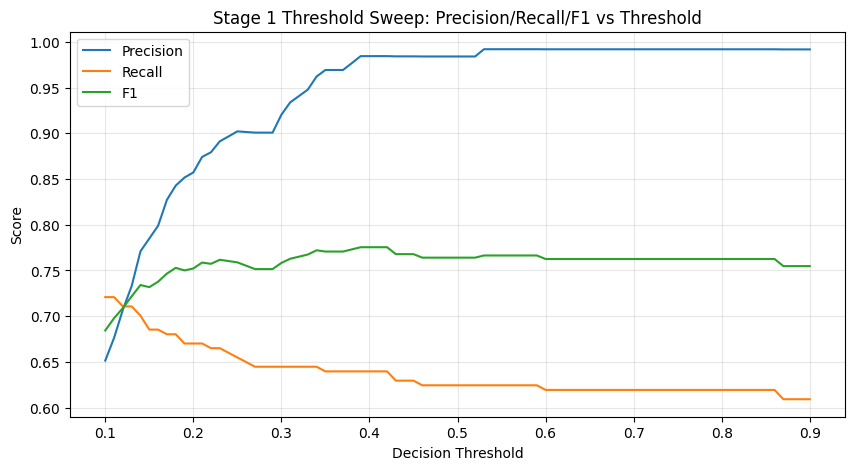

Selection rule: Best F1 among thresholds that improve recall vs 0.5
Best threshold: 0.39
Validation -> Precision: 0.9844, Recall: 0.6396, F1: 0.7754
Test       -> Precision: 0.9704, Recall: 0.6640, F1: 0.7885


In [11]:
# Stage 1: Threshold optimization
threshold_grid = np.round(np.arange(0.10, 0.901, 0.01), 2)

stage1_model = train_xgb_classifier(X_train, y_train)
stage1_val_prob = stage1_model.predict_proba(X_val)[:, 1]
stage1_test_prob = stage1_model.predict_proba(X_test)[:, 1]

stage1_best_threshold, stage1_threshold_df, stage1_reason = threshold_search(
    y_true=y_val,
    y_prob=stage1_val_prob,
    thresholds=threshold_grid,
    base_recall=BASELINE_VAL_RECALL,
    )

stage1_val_metrics = evaluate_threshold(y_val, stage1_val_prob, stage1_best_threshold)
stage1_test_metrics = evaluate_threshold(y_test, stage1_test_prob, stage1_best_threshold)
stage1_test_pred = (stage1_test_prob >= stage1_best_threshold).astype(int)

plot_threshold_tradeoff(
    stage1_threshold_df,
    "Stage 1 Threshold Sweep: Precision/Recall/F1 vs Threshold",
)

record_result(
    run_id="stage1_threshold_opt",
    stage="1_threshold_optimization",
    model_name="XGB_default",
    threshold=stage1_best_threshold,
    val_metrics=stage1_val_metrics,
    test_metrics=stage1_test_metrics,
    notes=stage1_reason,
    )
save_artifact("stage1_threshold_opt", stage1_test_prob, stage1_test_pred)

print("Selection rule:", stage1_reason)
print(f"Best threshold: {stage1_best_threshold:.2f}")
print(
    f"Validation -> Precision: {stage1_val_metrics['precision']:.4f}, "
    f"Recall: {stage1_val_metrics['recall']:.4f}, F1: {stage1_val_metrics['f1']:.4f}"
)
print(
    f"Test       -> Precision: {stage1_test_metrics['precision']:.4f}, "
    f"Recall: {stage1_test_metrics['recall']:.4f}, F1: {stage1_test_metrics['f1']:.4f}"
)

## 2) Class Imbalance Handling: SMOTE + Tomek Links

Apply SMOTE + Tomek Links on the training split and compare against original training data under the same threshold-selection protocol.

In [12]:
# Stage 2: SMOTE + Tomek Links vs original
stage2_thresholds = np.round(np.arange(0.10, 0.901, 0.01), 2)

# Original dataset branch
stage2_orig_model = train_xgb_classifier(X_train, y_train)
stage2_orig_val_prob = stage2_orig_model.predict_proba(X_val)[:, 1]
stage2_orig_test_prob = stage2_orig_model.predict_proba(X_test)[:, 1]
stage2_orig_threshold, _, _ = threshold_search(
    y_true=y_val,
    y_prob=stage2_orig_val_prob,
    thresholds=stage2_thresholds,
    base_recall=BASELINE_VAL_RECALL,
    )
stage2_orig_val_metrics = evaluate_threshold(y_val, stage2_orig_val_prob, stage2_orig_threshold)
stage2_orig_test_metrics = evaluate_threshold(y_test, stage2_orig_test_prob, stage2_orig_threshold)
stage2_orig_test_pred = (stage2_orig_test_prob >= stage2_orig_threshold).astype(int)

record_result(
    run_id="stage2_original",
    stage="2_smote_tomek",
    model_name="XGB_original_training",
    threshold=stage2_orig_threshold,
    val_metrics=stage2_orig_val_metrics,
    test_metrics=stage2_orig_test_metrics,
    notes="Original train split",
    )
save_artifact("stage2_original", stage2_orig_test_prob, stage2_orig_test_pred)

# SMOTE + Tomek branch
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

stage2_smt_model = train_xgb_classifier(X_train_res, y_train_res)
stage2_smt_val_prob = stage2_smt_model.predict_proba(X_val)[:, 1]
stage2_smt_test_prob = stage2_smt_model.predict_proba(X_test)[:, 1]
stage2_smt_threshold, _, _ = threshold_search(
    y_true=y_val,
    y_prob=stage2_smt_val_prob,
    thresholds=stage2_thresholds,
    base_recall=BASELINE_VAL_RECALL,
    )
stage2_smt_val_metrics = evaluate_threshold(y_val, stage2_smt_val_prob, stage2_smt_threshold)
stage2_smt_test_metrics = evaluate_threshold(y_test, stage2_smt_test_prob, stage2_smt_threshold)
stage2_smt_test_pred = (stage2_smt_test_prob >= stage2_smt_threshold).astype(int)

record_result(
    run_id="stage2_smote_tomek",
    stage="2_smote_tomek",
    model_name="XGB_SMOTE_Tomek",
    threshold=stage2_smt_threshold,
    val_metrics=stage2_smt_val_metrics,
    test_metrics=stage2_smt_test_metrics,
    notes="SMOTE + Tomek Links on training split",
    )
save_artifact("stage2_smote_tomek", stage2_smt_test_prob, stage2_smt_test_pred)

stage2_compare = pd.DataFrame([
    {"setup": "original", **stage2_orig_test_metrics, "threshold": stage2_orig_threshold},
    {"setup": "smote_tomek", **stage2_smt_test_metrics, "threshold": stage2_smt_threshold},
]).sort_values(["f1", "recall"], ascending=False)

print("Resampled training shape:", X_train_res.shape)
print("Original training class ratio:", y_train.mean())
print("Resampled training class ratio:", y_train_res.mean())
display(stage2_compare)

Resampled training shape: (124940, 148)
Original training class ratio: 0.012413381310790214
Resampled training class ratio: 0.5


,setup,threshold,precision,recall,f1
1,smote_tomek,0.73,0.982036,0.663968,0.792271
0,original,0.39,0.970414,0.663968,0.788462


## 3) Cost-Sensitive Learning

Tune `scale_pos_weight` and false-negative penalty (sample weighting) to bias training toward cancellation detection.

In [13]:
# Stage 3: Cost-sensitive learning (scale_pos_weight + FN penalty)
scale_pos_grid = [1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0]
fn_penalty_grid = [1.0, 1.5, 2.0, 3.0]

stage3_rows = []
best_stage3 = None

for spw in scale_pos_grid:
    for fn_penalty in fn_penalty_grid:
        params = {"scale_pos_weight": float(spw)}
        sample_weight = np.where(y_train.values == 1, fn_penalty, 1.0)

        model = train_xgb_classifier(
            X_fit=X_train,
            y_fit=y_train,
            params=params,
            sample_weight=sample_weight,
        )

        val_prob = model.predict_proba(X_val)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]

        best_thr, _, _ = threshold_search(
            y_true=y_val,
            y_prob=val_prob,
            thresholds=np.round(np.arange(0.10, 0.901, 0.01), 2),
            base_recall=BASELINE_VAL_RECALL,
        )

        val_metrics = evaluate_threshold(y_val, val_prob, best_thr)
        test_metrics = evaluate_threshold(y_test, test_prob, best_thr)

        row = {
            "scale_pos_weight": spw,
            "fn_penalty": fn_penalty,
            "threshold": best_thr,
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
        }
        stage3_rows.append(row)

stage3_df = pd.DataFrame(stage3_rows).sort_values(
    ["val_f1", "val_recall", "val_precision"],
    ascending=[False, False, False],
).reset_index(drop=True)

goal_candidates = stage3_df[
    (stage3_df["val_recall"] > BASELINE_VAL_RECALL)
    & (stage3_df["val_f1"] >= BASELINE_VAL_F1)
]

if not goal_candidates.empty:
    best_stage3 = goal_candidates.iloc[0].to_dict()
    best_stage3_note = "Meets goal on validation (higher recall, no F1 drop)."
else:
    best_stage3 = stage3_df.iloc[0].to_dict()
    best_stage3_note = "No full-goal config found; selected best validation F1/recall tradeoff."

stage3_run_id = "stage3_cost_sensitive"
record_result(
    run_id=stage3_run_id,
    stage="3_cost_sensitive",
    model_name="XGB_cost_sensitive",
    threshold=float(best_stage3["threshold"]),
    val_metrics={
        "precision": float(best_stage3["val_precision"]),
        "recall": float(best_stage3["val_recall"]),
        "f1": float(best_stage3["val_f1"]),
    },
    test_metrics={
        "precision": float(best_stage3["test_precision"]),
        "recall": float(best_stage3["test_recall"]),
        "f1": float(best_stage3["test_f1"]),
    },
    notes=best_stage3_note,
    )

# Refit and store artifact for best config only
best_stage3_model = train_xgb_classifier(
    X_fit=X_train,
    y_fit=y_train,
    params={"scale_pos_weight": float(best_stage3["scale_pos_weight"])},
    sample_weight=np.where(y_train.values == 1, float(best_stage3["fn_penalty"]), 1.0),
)
best_stage3_test_prob = best_stage3_model.predict_proba(X_test)[:, 1]
best_stage3_test_pred = (best_stage3_test_prob >= float(best_stage3["threshold"])).astype(int)
save_artifact(stage3_run_id, best_stage3_test_prob, best_stage3_test_pred)

BEST_COST_PARAMS = {"scale_pos_weight": float(best_stage3["scale_pos_weight"])}
BEST_COST_FN_PENALTY = float(best_stage3["fn_penalty"])
BEST_COST_THRESHOLD = float(best_stage3["threshold"])

print(best_stage3_note)
print("Best cost-sensitive config:")
print(
    f"scale_pos_weight={BEST_COST_PARAMS['scale_pos_weight']}, "
    f"fn_penalty={BEST_COST_FN_PENALTY}, threshold={BEST_COST_THRESHOLD:.2f}"
)
display(stage3_df.head(12))

Meets goal on validation (higher recall, no F1 drop).
Best cost-sensitive config:
scale_pos_weight=1.0, fn_penalty=2.0, threshold=0.46


,scale_pos_weight,fn_penalty,threshold,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1
0,1.0,2.0,0.46,0.984615,0.649746,0.782875,0.970414,0.663968,0.788462
1,1.5,3.0,0.54,0.977099,0.649746,0.780488,0.964912,0.668016,0.789474
2,7.0,1.0,0.66,0.992126,0.639594,0.777778,0.976190,0.663968,0.790361
3,1.0,1.5,0.31,0.942029,0.659898,0.776119,0.937853,0.672065,0.783019
4,10.0,3.0,0.80,0.962406,0.649746,0.775758,0.970238,0.659919,0.785542
5,1.0,1.0,0.39,0.984375,0.639594,0.775385,0.970414,0.663968,0.788462
6,1.5,2.0,0.52,0.984375,0.639594,0.775385,0.970588,0.668016,0.791367
7,2.0,1.0,0.52,0.984375,0.639594,0.775385,0.981928,0.659919,0.789346
8,2.0,2.0,0.54,0.984375,0.639594,0.775385,0.970414,0.663968,0.788462
9,3.0,1.5,0.59,0.984375,0.639594,0.775385,0.987952,0.663968,0.794189


## 4) Focal Loss (Custom Objective)

Train XGBoost with focal loss and compare against standard log-loss under threshold optimization.

In [14]:
# Stage 4: Focal loss vs standard log-loss
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def focal_binary_object(alpha: float = 0.25, gamma: float = 2.0):
    def _focal_obj(predt: np.ndarray, dtrain: xgb.DMatrix):
        y_true = dtrain.get_label()
        p = sigmoid(predt)

        focal_factor = alpha * y_true * ((1.0 - p) ** gamma) + (1.0 - alpha) * (1.0 - y_true) * (p ** gamma)
        grad = (p - y_true) * focal_factor
        hess = p * (1.0 - p) * focal_factor
        hess = np.clip(hess, 1e-6, None)
        return grad, hess

    return _focal_obj

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

base_booster_params = {
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": RANDOM_STATE,
    "tree_method": "hist",
}

# Standard log-loss baseline
logloss_params = {
    **base_booster_params,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
}
logloss_booster = xgb.train(
    params=logloss_params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=[(dval, "val")],
    verbose_eval=False,
    )

logloss_val_prob = logloss_booster.predict(dval)
logloss_test_prob = logloss_booster.predict(dtest)
logloss_thr, _, _ = threshold_search(
    y_true=y_val,
    y_prob=logloss_val_prob,
    thresholds=np.round(np.arange(0.10, 0.901, 0.01), 2),
    base_recall=BASELINE_VAL_RECALL,
)
logloss_val_metrics = evaluate_threshold(y_val, logloss_val_prob, logloss_thr)
logloss_test_metrics = evaluate_threshold(y_test, logloss_test_prob, logloss_thr)
logloss_test_pred = (logloss_test_prob >= logloss_thr).astype(int)

record_result(
    run_id="stage4_logloss",
    stage="4_focal_loss",
    model_name="XGB_logloss",
    threshold=logloss_thr,
    val_metrics=logloss_val_metrics,
    test_metrics=logloss_test_metrics,
    notes="Standard XGBoost objective",
)
save_artifact("stage4_logloss", logloss_test_prob, logloss_test_pred)

# Focal loss model
focal_booster = xgb.train(
    params=base_booster_params,
    dtrain=dtrain,
    num_boost_round=500,
    obj=focal_binary_object(alpha=0.25, gamma=2.0),
    evals=[(dval, "val")],
    verbose_eval=False,
    )

focal_val_margin = focal_booster.predict(dval, output_margin=True)
focal_test_margin = focal_booster.predict(dtest, output_margin=True)
focal_val_prob = sigmoid(focal_val_margin)
focal_test_prob = sigmoid(focal_test_margin)

focal_thr, _, _ = threshold_search(
    y_true=y_val,
    y_prob=focal_val_prob,
    thresholds=np.round(np.arange(0.10, 0.901, 0.01), 2),
    base_recall=BASELINE_VAL_RECALL,
)
focal_val_metrics = evaluate_threshold(y_val, focal_val_prob, focal_thr)
focal_test_metrics = evaluate_threshold(y_test, focal_test_prob, focal_thr)
focal_test_pred = (focal_test_prob >= focal_thr).astype(int)

record_result(
    run_id="stage4_focal",
    stage="4_focal_loss",
    model_name="XGB_focal_loss",
    threshold=focal_thr,
    val_metrics=focal_val_metrics,
    test_metrics=focal_test_metrics,
    notes="Custom focal loss objective",
)
save_artifact("stage4_focal", focal_test_prob, focal_test_pred)

stage4_compare = pd.DataFrame([
    {"objective": "logloss", **logloss_test_metrics, "threshold": logloss_thr},
    {"objective": "focal_loss", **focal_test_metrics, "threshold": focal_thr},
]).sort_values(["f1", "recall"], ascending=False)

display(stage4_compare)

,objective,threshold,precision,recall,f1
0,logloss,0.37,0.964912,0.668016,0.789474
1,focal_loss,0.39,0.958824,0.659919,0.781775


## 5) Two-Stage Model

Stage 1 prioritizes recall with a lower threshold, then Stage 2 refines Stage 1 positive cases to recover precision.

In [15]:
# Stage 5: Two-stage model (high-recall gate + precision refiner)
stage1_params = BEST_COST_PARAMS if "BEST_COST_PARAMS" in globals() else {}
stage1_fn_penalty = BEST_COST_FN_PENALTY if "BEST_COST_FN_PENALTY" in globals() else 1.0

stage5_model_stage1 = train_xgb_classifier(
    X_fit=X_train,
    y_fit=y_train,
    params=stage1_params,
    sample_weight=np.where(y_train.values == 1, stage1_fn_penalty, 1.0),
)

stage5_val_prob_stage1 = stage5_model_stage1.predict_proba(X_val)[:, 1]
stage5_test_prob_stage1 = stage5_model_stage1.predict_proba(X_test)[:, 1]

stage5_gate_df = pd.DataFrame([
    evaluate_threshold(y_val, stage5_val_prob_stage1, float(t))
    for t in np.round(np.arange(0.10, 0.901, 0.01), 2)
])
stage5_gate_candidates = stage5_gate_df[stage5_gate_df["precision"] >= 0.10]
if not stage5_gate_candidates.empty:
    gate_row = stage5_gate_candidates.sort_values(["recall", "f1"], ascending=[False, False]).iloc[0]
else:
    gate_row = stage5_gate_df.sort_values(["recall", "f1"], ascending=[False, False]).iloc[0]

stage5_gate_threshold = float(gate_row["threshold"])
stage5_val_pred_stage1 = (stage5_val_prob_stage1 >= stage5_gate_threshold).astype(int)
stage5_test_pred_stage1 = (stage5_test_prob_stage1 >= stage5_gate_threshold).astype(int)

stage5_val_metrics_stage1 = {
    "precision": float(precision_score(y_val, stage5_val_pred_stage1, zero_division=0)),
    "recall": float(recall_score(y_val, stage5_val_pred_stage1, zero_division=0)),
    "f1": float(f1_score(y_val, stage5_val_pred_stage1, zero_division=0)),
}
stage5_test_metrics_stage1 = {
    "precision": float(precision_score(y_test, stage5_test_pred_stage1, zero_division=0)),
    "recall": float(recall_score(y_test, stage5_test_pred_stage1, zero_division=0)),
    "f1": float(f1_score(y_test, stage5_test_pred_stage1, zero_division=0)),
}

record_result(
    run_id="stage5_stage1_gate",
    stage="5_two_stage",
    model_name="XGB_stage1_high_recall",
    threshold=stage5_gate_threshold,
    val_metrics=stage5_val_metrics_stage1,
    test_metrics=stage5_test_metrics_stage1,
    notes="High-recall gate model",
)
save_artifact("stage5_stage1_gate", stage5_test_prob_stage1, stage5_test_pred_stage1)

# Train stage 2 only on stage-1 positive candidates from training split
stage1_train_prob = stage5_model_stage1.predict_proba(X_train)[:, 1]
stage1_train_mask = stage1_train_prob >= stage5_gate_threshold
stage1_val_mask = stage5_val_prob_stage1 >= stage5_gate_threshold

X_train_stage2 = X_train.loc[stage1_train_mask].copy()
y_train_stage2 = y_train.loc[stage1_train_mask].copy()
X_val_stage2 = X_val.loc[stage1_val_mask].copy()
y_val_stage2 = y_val.loc[stage1_val_mask].copy()

if len(X_train_stage2) < 200 or y_train_stage2.nunique() < 2 or len(X_val_stage2) < 50 or y_val_stage2.nunique() < 2:
    print("Stage 2 had insufficient class diversity. Falling back to stage-1 predictions.")
    stage5_final_val_pred = stage5_val_pred_stage1
    stage5_final_test_pred = stage5_test_pred_stage1
    stage5_combined_test_score = stage5_test_prob_stage1.copy()
    stage5_stage2_threshold = 0.5
else:
    stage5_model_stage2 = train_xgb_classifier(
        X_fit=X_train_stage2,
        y_fit=y_train_stage2,
        params={"max_depth": 4, "n_estimators": 300, "learning_rate": 0.07},
        sample_weight=np.where(y_train_stage2.values == 1, 1.5, 1.0),
    )

    stage2_val_prob = stage5_model_stage2.predict_proba(X_val_stage2)[:, 1]
    stage5_stage2_threshold, _, _ = threshold_search(
        y_true=y_val_stage2,
        y_prob=stage2_val_prob,
        thresholds=np.round(np.arange(0.10, 0.901, 0.01), 2),
        base_recall=None,
    )

    stage2_val_pred = (stage2_val_prob >= stage5_stage2_threshold).astype(int)
    stage5_final_val_pred = np.zeros(len(y_val), dtype=int)
    stage5_final_val_pred[stage1_val_mask] = stage2_val_pred

    stage5_final_test_pred = np.zeros(len(y_test), dtype=int)
    stage5_combined_test_score = stage5_test_prob_stage1.copy()
    stage1_test_mask = stage5_test_prob_stage1 >= stage5_gate_threshold

    if stage1_test_mask.any():
        stage2_test_prob = stage5_model_stage2.predict_proba(X_test.loc[stage1_test_mask])[:, 1]
        stage2_test_pred = (stage2_test_prob >= stage5_stage2_threshold).astype(int)
        stage5_final_test_pred[stage1_test_mask] = stage2_test_pred
        stage5_combined_test_score[stage1_test_mask] = stage5_test_prob_stage1[stage1_test_mask] * stage2_test_prob

stage5_val_metrics_two_stage = {
    "precision": float(precision_score(y_val, stage5_final_val_pred, zero_division=0)),
    "recall": float(recall_score(y_val, stage5_final_val_pred, zero_division=0)),
    "f1": float(f1_score(y_val, stage5_final_val_pred, zero_division=0)),
}
stage5_test_metrics_two_stage = {
    "precision": float(precision_score(y_test, stage5_final_test_pred, zero_division=0)),
    "recall": float(recall_score(y_test, stage5_final_test_pred, zero_division=0)),
    "f1": float(f1_score(y_test, stage5_final_test_pred, zero_division=0)),
}

record_result(
    run_id="stage5_two_stage",
    stage="5_two_stage",
    model_name="TwoStage_XGB",
    threshold=stage5_gate_threshold,
    val_metrics=stage5_val_metrics_two_stage,
    test_metrics=stage5_test_metrics_two_stage,
    notes=f"Stage1_thr={stage5_gate_threshold:.2f}; Stage2_thr={stage5_stage2_threshold:.2f}",
)
save_artifact("stage5_two_stage", stage5_combined_test_score, stage5_final_test_pred)

stage5_compare = pd.DataFrame([
    {"model": "stage1_high_recall", **stage5_test_metrics_stage1},
    {"model": "two_stage", **stage5_test_metrics_two_stage},
]).sort_values(["f1", "recall"], ascending=False)

print(f"Stage 1 gate threshold: {stage5_gate_threshold:.2f}")
print(f"Stage 2 threshold: {stage5_stage2_threshold:.2f}")
display(stage5_compare)

Stage 1 gate threshold: 0.12
Stage 2 threshold: 0.48


,model,precision,recall,f1
1,two_stage,0.706612,0.692308,0.699387
0,stage1_high_recall,0.632353,0.696356,0.662813


## 6) Cross-Validation (Stratified K-Fold)

Use 5-fold stratified CV and report mean precision, recall, and F1.

In [16]:
# Stage 6: Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

cv_params = BEST_COST_PARAMS if "BEST_COST_PARAMS" in globals() else {}
cv_fn_penalty = BEST_COST_FN_PENALTY if "BEST_COST_FN_PENALTY" in globals() else 1.0

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full), start=1):
    X_tr = X_train_full.iloc[train_idx]
    y_tr = y_train_full.iloc[train_idx]
    X_va = X_train_full.iloc[val_idx]
    y_va = y_train_full.iloc[val_idx]

    sample_weight = np.where(y_tr.values == 1, cv_fn_penalty, 1.0)
    cv_model = train_xgb_classifier(
        X_fit=X_tr,
        y_fit=y_tr,
        params=cv_params,
        sample_weight=sample_weight,
    )

    va_prob = cv_model.predict_proba(X_va)[:, 1]
    va_base_recall = evaluate_threshold(y_va, va_prob, 0.5)["recall"]
    va_thr, _, _ = threshold_search(
        y_true=y_va,
        y_prob=va_prob,
        thresholds=np.round(np.arange(0.10, 0.901, 0.01), 2),
        base_recall=va_base_recall,
    )
    va_metrics = evaluate_threshold(y_va, va_prob, va_thr)

    cv_rows.append({
        "fold": fold,
        "threshold": va_thr,
        "precision": va_metrics["precision"],
        "recall": va_metrics["recall"],
        "f1": va_metrics["f1"],
    })

cv_df = pd.DataFrame(cv_rows)
cv_mean = cv_df[["precision", "recall", "f1"]].mean().to_dict()
cv_std = cv_df[["precision", "recall", "f1"]].std().to_dict()

print("5-Fold Stratified CV Metrics")
display(cv_df)
print(
    f"Mean Precision={cv_mean['precision']:.4f} (+/- {cv_std['precision']:.4f}), "
    f"Mean Recall={cv_mean['recall']:.4f} (+/- {cv_std['recall']:.4f}), "
    f"Mean F1={cv_mean['f1']:.4f} (+/- {cv_std['f1']:.4f})"
)

5-Fold Stratified CV Metrics


,fold,threshold,precision,recall,f1
0,1,0.39,0.928571,0.590909,0.722222
1,2,0.45,0.984127,0.626263,0.765432
2,3,0.29,0.897959,0.670051,0.767442
3,4,0.30,0.898438,0.583756,0.707692
4,5,0.45,0.962121,0.644670,0.772036


Mean Precision=0.9342 (+/- 0.0384), Mean Recall=0.6231 (+/- 0.0363), Mean F1=0.7470 (+/- 0.0298)


## 7) Evaluation

Select the best run under the constraint of non-decreasing F1, then show confusion matrix and precision-recall diagnostics.

Selected highest test recall among runs with test F1 >= baseline test F1.
Best run id: stage4_logloss
Best model: XGB_logloss
Best threshold: 0.37
Test Precision: 0.9649
Test Recall:    0.6680
Test F1:        0.7895


,run_id,stage,model,threshold,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,notes
0,stage5_stage1_gate,5_two_stage,XGB_stage1_high_recall,0.12,0.615063,0.746193,0.674312,0.632353,0.696356,0.662813,High-recall gate model
1,stage5_two_stage,5_two_stage,TwoStage_XGB,0.12,0.687805,0.715736,0.701493,0.706612,0.692308,0.699387,Stage1_thr=0.12; Stage2_thr=0.48
2,stage4_logloss,4_focal_loss,XGB_logloss,0.37,0.976923,0.644670,0.776758,0.964912,0.668016,0.789474,Standard XGBoost objective
3,stage2_smote_tomek,2_smote_tomek,XGB_SMOTE_Tomek,0.73,0.976378,0.629442,0.765432,0.982036,0.663968,0.792271,SMOTE + Tomek Links on training split
4,stage1_threshold_opt,1_threshold_optimization,XGB_default,0.39,0.984375,0.639594,0.775385,0.970414,0.663968,0.788462,Best F1 among thresholds that improve recall v...
5,stage2_original,2_smote_tomek,XGB_original_training,0.39,0.984375,0.639594,0.775385,0.970414,0.663968,0.788462,Original train split
6,stage3_cost_sensitive,3_cost_sensitive,XGB_cost_sensitive,0.46,0.984615,0.649746,0.782875,0.970414,0.663968,0.788462,"Meets goal on validation (higher recall, no F1..."
7,stage4_focal,4_focal_loss,XGB_focal_loss,0.39,0.976562,0.634518,0.769231,0.958824,0.659919,0.781775,Custom focal loss objective


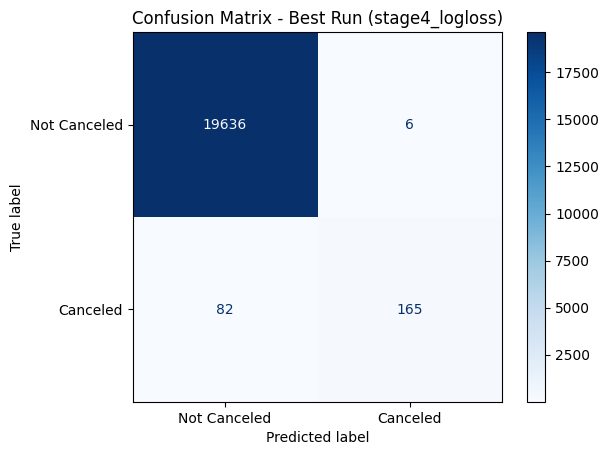

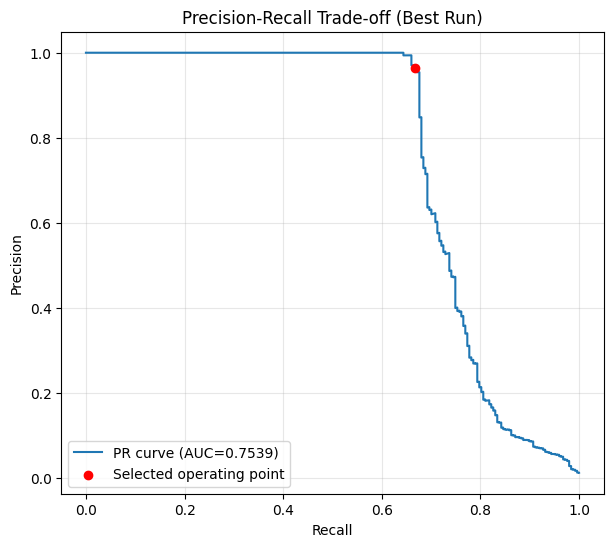

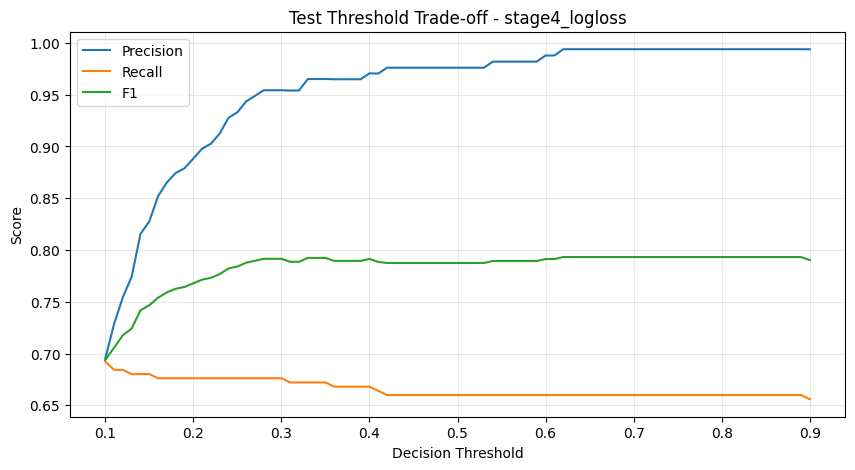

In [17]:
# Stage 7: Evaluation and trade-off visualization
if len(experiment_results) == 0:
    raise RuntimeError("No experiments recorded. Run previous stage cells first.")

results_df = pd.DataFrame(experiment_results).sort_values(
    ["test_recall", "test_f1", "test_precision"],
    ascending=[False, False, False],
).reset_index(drop=True)

goal_df = results_df[results_df["test_f1"] >= BASELINE_TEST_F1]
if not goal_df.empty:
    BEST_RUN_ROW = goal_df.sort_values(
        ["test_recall", "test_f1", "test_precision"],
        ascending=[False, False, False],
    ).iloc[0]
    BEST_SELECTION_RULE = "Selected highest test recall among runs with test F1 >= baseline test F1."
else:
    BEST_RUN_ROW = results_df.sort_values(
        ["test_f1", "test_recall", "test_precision"],
        ascending=[False, False, False],
    ).iloc[0]
    BEST_SELECTION_RULE = "No run met non-decreasing F1 constraint on test; selected best test F1."

BEST_RUN_ID = str(BEST_RUN_ROW["run_id"])
BEST_ARTIFACT = experiment_artifacts[BEST_RUN_ID]
BEST_TEST_PROB = BEST_ARTIFACT["y_prob_test"]
BEST_TEST_PRED = BEST_ARTIFACT["y_pred_test"]

best_precision = precision_score(y_test, BEST_TEST_PRED, zero_division=0)
best_recall = recall_score(y_test, BEST_TEST_PRED, zero_division=0)
best_f1 = f1_score(y_test, BEST_TEST_PRED, zero_division=0)

print(BEST_SELECTION_RULE)
print("Best run id:", BEST_RUN_ID)
print("Best model:", BEST_RUN_ROW["model"] )
print(f"Best threshold: {BEST_RUN_ROW['threshold']:.2f}")
print(f"Test Precision: {best_precision:.4f}")
print(f"Test Recall:    {best_recall:.4f}")
print(f"Test F1:        {best_f1:.4f}")

display(results_df)

# Confusion matrix
cm = confusion_matrix(y_test, BEST_TEST_PRED)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Canceled", "Canceled"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - Best Run ({BEST_RUN_ID})")
plt.show()

# Precision-recall curve
pr_precision, pr_recall, _ = precision_recall_curve(y_test, BEST_TEST_PROB)
pr_auc = auc(pr_recall, pr_precision)

plt.figure(figsize=(7, 6))
plt.plot(pr_recall, pr_precision, label=f"PR curve (AUC={pr_auc:.4f})")
plt.scatter(
    [best_recall],
    [best_precision],
    color="red",
    label="Selected operating point",
    zorder=5,
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off (Best Run)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Clear threshold trade-off plot for selected run
tradeoff_rows = [
    evaluate_threshold(y_test, BEST_TEST_PROB, float(t))
    for t in np.round(np.arange(0.10, 0.901, 0.01), 2)
]
tradeoff_df = pd.DataFrame(tradeoff_rows)
plot_threshold_tradeoff(tradeoff_df, f"Test Threshold Trade-off - {BEST_RUN_ID}")

## 8) Final Output

Summarize the best configuration, selected threshold, and final metrics.

In [18]:
# Stage 8: Final output block
final_summary = {
    "best_run_id": BEST_RUN_ID,
    "best_stage": str(BEST_RUN_ROW["stage"]),
    "best_model": str(BEST_RUN_ROW["model"]),
    "best_threshold": float(BEST_RUN_ROW["threshold"]),
    "final_precision": float(best_precision),
    "final_recall": float(best_recall),
    "final_f1": float(best_f1),
    "baseline_test_f1": float(BASELINE_TEST_F1),
    "selection_rule": BEST_SELECTION_RULE,
    "notes": str(BEST_RUN_ROW["notes"]),
}

print("Best model configuration")
print("- Run ID:", final_summary["best_run_id"] )
print("- Stage:", final_summary["best_stage"] )
print("- Model:", final_summary["best_model"] )
print(f"- Best threshold: {final_summary['best_threshold']:.2f}")
print(f"- Final Recall: {final_summary['final_recall']:.4f}")
print(f"- Final Precision: {final_summary['final_precision']:.4f}")
print(f"- Final F1-score: {final_summary['final_f1']:.4f}")
print(f"- Baseline Test F1-score: {final_summary['baseline_test_f1']:.4f}")
print("- Selection Rule:", final_summary["selection_rule"])
print("- Notes:", final_summary["notes"])

display(pd.DataFrame([final_summary]))

Best model configuration
- Run ID: stage4_logloss
- Stage: 4_focal_loss
- Model: XGB_logloss
- Best threshold: 0.37
- Final Recall: 0.6680
- Final Precision: 0.9649
- Final F1-score: 0.7895
- Baseline Test F1-score: 0.7874
- Selection Rule: Selected highest test recall among runs with test F1 >= baseline test F1.
- Notes: Standard XGBoost objective


,best_run_id,best_stage,best_model,best_threshold,final_precision,final_recall,final_f1,baseline_test_f1,selection_rule,notes
0,stage4_logloss,4_focal_loss,XGB_logloss,0.37,0.964912,0.668016,0.789474,0.78744,Selected highest test recall among runs with t...,Standard XGBoost objective
